# Melinoë — quickstart

Build one model, then ask it different questions. Run top to bottom.

In [1]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, Melinoe.Models, ApproxFun, PyPlot, Printf
PyPlot.svg(true);

  Activating project at `~/code/ge-julia/examples`


## A model

In [2]:
m = PREM()                    # or Mars(), Ganymede(), Kelvin(), or your own

@printf("%s   R = %.0f km   ρ̄ = %.0f kg/m³   M = %.4e kg\n\n",
        m.name, m.R_SI/1e3, m.ρ̄_SI, (4π/3)*m.R_SI^3*m.ρ̄_SI)
for (i, l) in enumerate(m.layers)
    a, b = leftendpoint(l.domain), rightendpoint(l.domain)
    @printf("%2d  %6.0f – %6.0f km  %-5s  n=%-4d ρ = %6.0f kg/m³\n", i,
            a*m.R_SI/1e3, b*m.R_SI/1e3, is_fluid(l) ? "fluid" : "solid",
            l.n, l.ρ₀((a+b)/2)*m.ρ̄_SI)
end

PREM   R = 6371 km   ρ̄ = 5515 kg/m³   M = 5.9739e+24 kg

 1       0 –   1222 km  solid  n=64   ρ =  13004 kg/m³
 2    1222 –   3480 km  fluid  n=120  ρ =  11338 kg/m³
 3    3480 –   3630 km  solid  n=30   ρ =   5527 kg/m³
 4    3630 –   5600 km  solid  n=60   ρ =   4994 kg/m³
 5    5600 –   5701 km  solid  n=30   ρ =   4411 kg/m³
 6    5701 –   5771 km  solid  n=20   ρ =   3983 kg/m³
 7    5771 –   5971 km  solid  n=30   ρ =   3849 kg/m³
 8    5971 –   6151 km  solid  n=30   ρ =   3489 kg/m³
 9    6151 –   6291 km  solid  n=20   ρ =   3366 kg/m³
10    6291 –   6347 km  solid  n=20   ρ =   3377 kg/m³
11    6347 –   6356 km  solid  n=15   ρ =   2899 kg/m³
12    6356 –   6371 km  solid  n=15   ρ =   2599 kg/m³


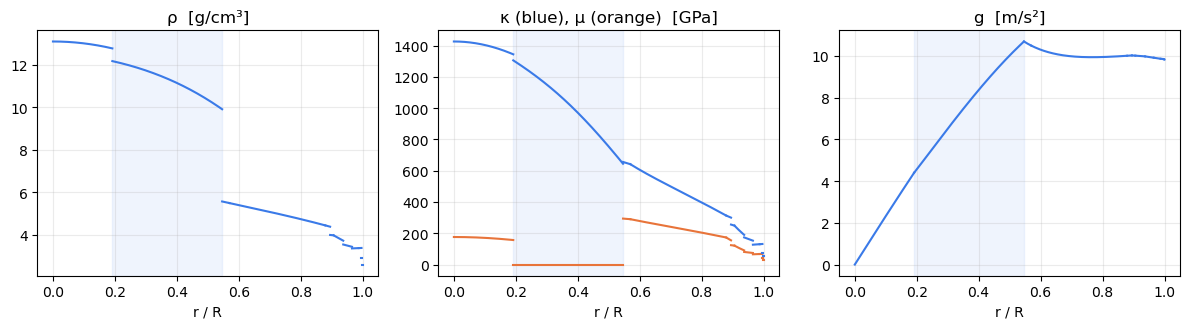

In [3]:
fig, ax = subplots(1, 3, figsize = (12, 3.4), sharex = true)
g_unit = m.ω_unit^2 * m.R_SI
for l in m.layers
    rr = range(leftendpoint(l.domain), rightendpoint(l.domain), 200)
    ax[1].plot(rr, l.ρ₀.(rr) .* m.ρ̄_SI ./ 1e3, color = "#3a7ae8")
    ax[2].plot(rr, [l.κ(r) for r in rr] .* m.p_unit ./ 1e9, color = "#3a7ae8")
    ax[2].plot(rr, [l.μ(r) for r in rr] .* m.p_unit ./ 1e9, color = "#e8743a")
    ax[3].plot(rr, l.g₀.(rr) .* g_unit, color = "#3a7ae8")
    is_fluid(l) && foreach(a -> a.axvspan(first(rr), last(rr), color = "#3a7ae8", alpha = .08), ax)
end
for (a, t) in zip(ax, ("ρ  [g/cm³]", "κ (blue), μ (orange)  [GPa]", "g  [m/s²]"))
    a.set_title(t); a.set_xlabel("r / R"); a.grid(alpha = .25)
end
tight_layout(); gcf()

## Ask it things

In [4]:
ln = love_numbers(m)                         # static tidal Love numbers, ℓ = 2
@printf("h₂ = %.4f   l₂ = %.4f   k₂ = %.4f      [PREM: 0.6032  0.0839  0.2980]\n",
        -ln.h, -ln.l, ln.k)

# Free modes need a NEUTRALLY stratified core, else the tabulated κ (N² ≠ 0)
# adds spurious g-modes below ₀S₂. `use_aw_oc` enforces N² = 0.
fm = free_modes(PREM(use_aw_oc = true))      # spheroidal ℓ = 2 eigenmodes
@printf("₀S₂…₇S₂ [min]  %s\n", join(round.(fm.T_min[1:8], digits = 2), "  "))
@printf("     MINEOS     %s\n",
        join([53.89, 24.52, 17.77, 15.07, 9.68, 7.97, 6.91, 6.62], "  "))

c = compliances(m; core_layer = 2)           # Sasao κ, ξ, γ, β
@printf("\nκ = %.4e  ξ = %.4e  γ = %.4e  β = %.4e   (Betti %.0e)\n",
        c.κ, c.ξ, c.γ, c.β, c.betti)
println("Dumberry (2009)   1.0380e-03  2.2190e-04  1.9620e-03  6.1510e-04")

h₂ = 0.6034   l₂ = 0.0840   k₂ = 0.2981      [PREM: 0.6032  0.0839  0.2980]
₀S₂…₇S₂ [min]  53.61  24.35  17.36  14.98  9.63  7.93  6.77  6.58
     MINEOS     53.89  24.52  17.77  15.07  9.68  7.97  6.91  6.62

κ = 1.0355e-03  ξ = 2.2136e-04  γ = 1.9599e-03  β = 6.1441e-04   (Betti -2e-06)
Dumberry (2009)   1.0380e-03  2.2190e-04  1.9620e-03  6.1510e-04


## The matrices behind all of it

Every verb above assembles the same pencil `A x = ω² B x` in `[U; V/P; δφ]`.
A piecewise-constant two-layer body makes the structure plain — constant `ρ, κ, μ`
leave the multiplication operators diagonal, so what shows is the banding of the
spectral derivatives.

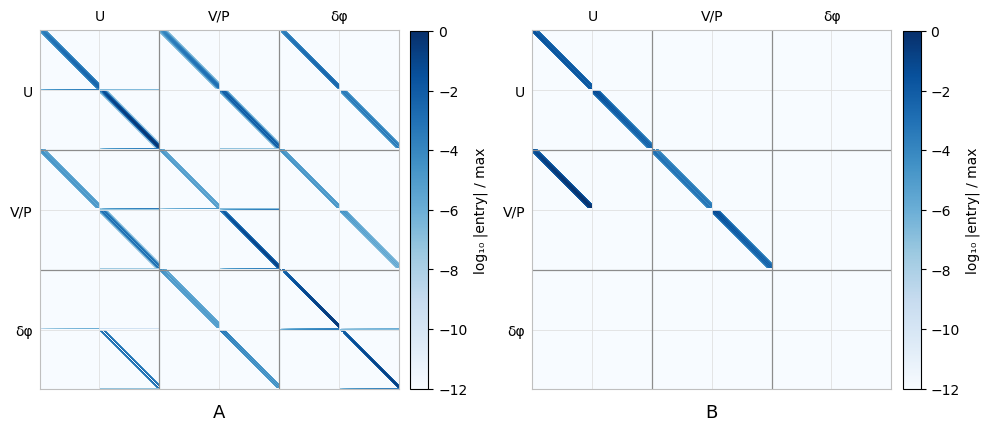

In [5]:
# fluid core | solid mantle, ρ mean-normalised so 3∫ρr²dr = 1 (⇒ g(1) = 1).
# This is also how you build your own model.
ρc, ρm = 3.0, 1.0
nrm = 3*(poly_r2_integral([ρc], 0.0, 0.5) + poly_r2_integral([ρm], 0.5, 1.0))
mm = build_model("2-layer", [0.0..0.5, 0.5..1.0], [[ρc]/nrm, [ρm]/nrm],
                 [r -> 2.0, r -> 2.0], [r -> 0.0, r -> 0.8], [60, 60];
                 R_SI = 6.0e6, ρ̄_SI = 5000.0, aw = [false, true])

A, B, ops, ns = assemble_planet(mm.layers, 2)
N = sum(ns)

lbl  = ["U", "V/P", "δφ"]
cmap = "Blues"                                   # log₁₀|entry| / max
# share of entries within six decades of the largest — an absolute cutoff is
# meaningless here, the entries span tens of decades
nnz(M) = 100 * count(x -> abs(x) > 1e-6 * maximum(abs, M), M) / length(M)

function spyax(a, M, t, nb)                      # nb = how many N-sized field blocks
    im = a.imshow(log10.(abs.(M) ./ maximum(abs, M) .+ 1e-18), cmap = cmap,
                  vmin = -12, vmax = 0, interpolation = "nearest")
    for o in 0:nb-1                              # layer boundary inside each block
        a.axhline(ns[1]+o*N-.5, color = "0.88", lw = .6)
        a.axvline(ns[1]+o*N-.5, color = "0.88", lw = .6)
    end
    for k in 1:nb-1                              # field blocks
        a.axhline(k*N-.5, color = "0.55", lw = .9); a.axvline(k*N-.5, color = "0.55", lw = .9)
    end
    a.set_xticks([(k-.5)*N for k in 1:nb]); a.set_yticks([(k-.5)*N for k in 1:nb])
    a.set_xticklabels(lbl[1:nb]); a.set_yticklabels(lbl[1:nb])
    a.tick_params(length = 0, labeltop = true, labelbottom = false, pad = 5)
    for sp in ("top", "bottom", "left", "right")
        a.spines[sp].set_color("0.75"); a.spines[sp].set_linewidth(.8)
    end
    a.set_title(t, y = -0.10, fontsize = 13)
    return im
end

fig, ax = subplots(1, 2, figsize = (10, 4.4))
for (a, M, t) in zip(ax, (A, B), ("A", "B"))
    fig.colorbar(spyax(a, M, t, 3), ax = a, fraction = .046, pad = .03,
                 label = "log₁₀ |entry| / max")
end
tight_layout(); gcf()

Two diagonal bands per block, one per layer — the spectral derivatives, bandwidth
~5 of 60. The full horizontal lines are the boundary and interface rows.

`B`'s whole `δφ` row and column are empty: self-gravity is instantaneous, so it
carries no mass term. The pencil is therefore singular; `free_modes` solves it as
it stands and discards what the singularity produces.

In [6]:
@printf("δφ block of B is all zero: %s\n", all(iszero, B[2N+1:3N, :]))
fm2 = free_modes(mm)
@printf("%d eigenvalues → %d physical modes\n", 3N, length(fm2.ωs))

δφ block of B is all zero: true
360 eigenvalues → 103 physical modes


In [7]:
mc = load_planet_csv(joinpath(@__DIR__, "PREM_1s.csv"))   # a published table
@printf("%d layers, ρ̄ = %.1f kg/m³, k₂ = %.4f\n", length(mc.layers), mc.ρ̄_SI,
        love_numbers(mc).k)
@printf("the 2-layer toy above:  k₂ = %.4f\n", love_numbers(mm).k)

13 layers, ρ̄ = 5514.2 kg/m³, k₂ = 0.3639
the 2-layer toy above:  k₂ = 0.2196


Next: the numbered notebooks derive all of this from scratch — Love numbers (1),
the static-fluid gauge and `dahlenize` (2), forcings and compliances (3), PREM
against published values (4), free modes against MINEOS (5).